In [6]:
# 1. Scan all variables for missing values and inconsistencies:
# First, let’s create a simple dataset with some potential issues like missing values and inconsistencies. 
# Afterward, we’ll perform data wrangling operations.
    
import pandas as pd
import numpy as np

# Creating a sample dataset
data = {
    'Student_ID': [1, 2, 3, 4, 5],
    'Math_Score': [90, np.nan, 80, 70, 85],
    'Science_Score': [85, 78, np.nan, 92, 88],
    'Age': [18, 19, 20, np.nan, 22],
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Other'],
    'Attendance': [95, 80, 100, 95, np.nan]
}

df = pd.DataFrame(data)

# Checking for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Checking for inconsistencies in Gender column
print("\nChecking for inconsistencies in 'Gender' column:")
print(df['Gender'].value_counts())

# We can see that there's a missing value in Age and Attendance, and there's also an "Other" category in Gender, which may be inconsistent.


Missing values in each column:
Student_ID       0
Math_Score       1
Science_Score    1
Age              1
Gender           0
Attendance       1
dtype: int64

Checking for inconsistencies in 'Gender' column:
Gender
Male      2
Female    2
Other     1
Name: count, dtype: int64


In [7]:
# 2. Handling Missing Values and Inconsistencies:

# Missing numeric values: We can either fill them with a mean, median, or use forward/backward fill methods.
# Missing categorical values: For categorical data like "Gender," we can handle missing values by replacing them
# with the most frequent value or a placeholder.

# Filling missing values for numeric columns with the mean of each column
df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].mean())
df['Science_Score'] = df['Science_Score'].fillna(df['Science_Score'].mean())
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Attendance'] = df['Attendance'].fillna(df['Attendance'].mean())

# For categorical variables like Gender, fill with the mode (most frequent value)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

# After handling missing values
print("\nDataset after handling missing values:")
print(df)



Dataset after handling missing values:
   Student_ID  Math_Score  Science_Score    Age  Gender  Attendance
0           1       90.00          85.00  18.00    Male        95.0
1           2       81.25          78.00  19.00  Female        80.0
2           3       80.00          85.75  20.00    Male       100.0
3           4       70.00          92.00  19.75  Female        95.0
4           5       85.00          88.00  22.00   Other        92.5


Math_Score outlier bounds: 72.5, 92.5

Outliers in Math_Score:
   Student_ID  Math_Score  Science_Score    Age  Gender  Attendance
3           4        70.0           92.0  19.75  Female        95.0


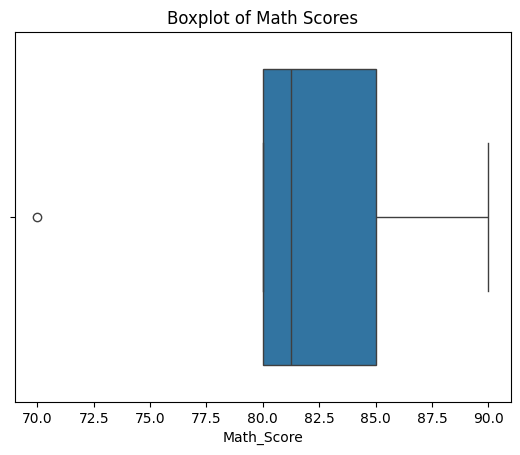

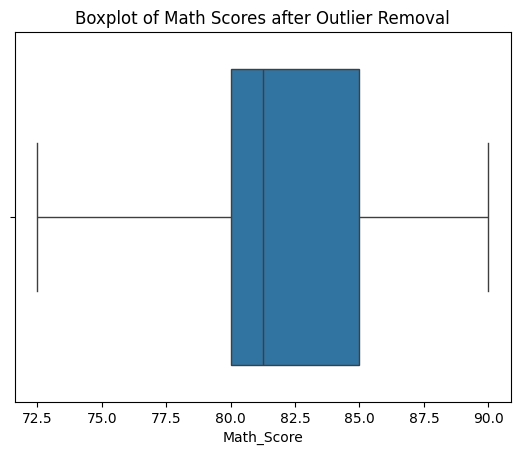

In [8]:
# 2. Scan all numeric variables for outliers:

# Now we check for outliers in numeric variables. 
# A typical method for detecting outliers is using the Interquartile Range (IQR), or we could use Z-scores.
import matplotlib.pyplot as plt
import seaborn as sns

# Checking for outliers using IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Detecting outliers in "Math_Score"
lower, upper = detect_outliers(df, 'Math_Score')
print(f"Math_Score outlier bounds: {lower}, {upper}")
print("\nOutliers in Math_Score:")
outliers = df[(df['Math_Score'] < lower) | (df['Math_Score'] > upper)]
print(outliers)

# Visualization to confirm the outliers
sns.boxplot(x=df['Math_Score'])
plt.title("Boxplot of Math Scores")
plt.show()

# Handling outliers: One option is to cap values beyond the outlier bounds
df['Math_Score'] = np.clip(df['Math_Score'], lower, upper)

# Visualize after handling outliers
sns.boxplot(x=df['Math_Score'])
plt.title("Boxplot of Math Scores after Outlier Removal")
plt.show()


Skewness of 'Attendance' before transformation: -0.9938079899999065
Skewness of 'Log_Attendance' after transformation: -1.0715556524352614


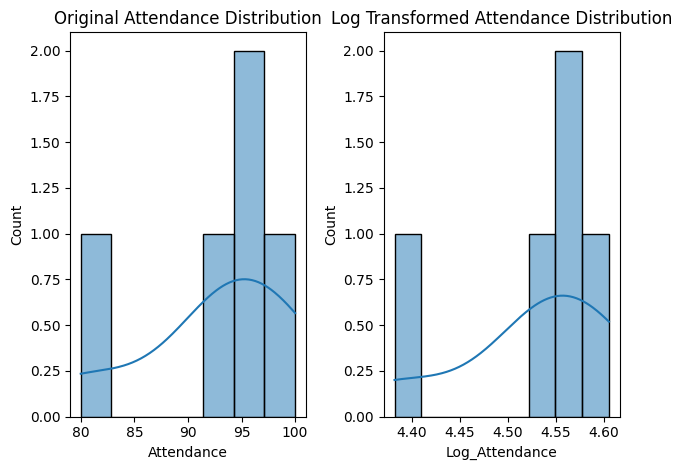

In [9]:
# 3. Apply data transformations:

# We will perform a transformation on one variable to reduce skewness. Skewness can cause problems in some models,
# so it is often useful to transform the data to approximate a normal distribution.

# Let’s use the log transformation to transform the "Attendance" variable, which often has a skewed distribution.
from scipy.stats import skew

# Checking the skewness of "Attendance" before transformation
print(f"Skewness of 'Attendance' before transformation: {skew(df['Attendance'])}")

# Apply log transformation on Attendance
df['Log_Attendance'] = np.log(df['Attendance'])

# Checking skewness after transformation
print(f"Skewness of 'Log_Attendance' after transformation: {skew(df['Log_Attendance'])}")

# Visualizing the distribution before and after the log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['Attendance'], kde=True)
plt.title("Original Attendance Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df['Log_Attendance'], kde=True)
plt.title("Log Transformed Attendance Distribution")
plt.tight_layout()
plt.show()
# Explanation of Transformation:
# Log Transformation: This transformation is applied to reduce positive skewness. 
# The log of data compresses large values and makes the distribution more symmetric and closer to a normal distribution.




In [10]:
print("\nFinal cleaned dataset:")
print(df)



Final cleaned dataset:
   Student_ID  Math_Score  Science_Score    Age  Gender  Attendance  \
0           1       90.00          85.00  18.00    Male        95.0   
1           2       81.25          78.00  19.00  Female        80.0   
2           3       80.00          85.75  20.00    Male       100.0   
3           4       72.50          92.00  19.75  Female        95.0   
4           5       85.00          88.00  22.00   Other        92.5   

   Log_Attendance  
0        4.553877  
1        4.382027  
2        4.605170  
3        4.553877  
4        4.527209  


In [11]:
#other methods than iqr
from scipy.stats import zscore

# Assuming df is your DataFrame and 'Math_Score' is a numeric column
z_scores = zscore(df['Math_Score'])
df['z_score'] = z_scores

# Identifying outliers with z-score greater than 3 or less than -3
outliers = df[ (df['z_score'] > 3) | (df['z_score'] < -3) ]
print(outliers)
# . Z-Score Method
# Description: The Z-score method involves calculating how many standard deviations a data point is from the mean of the dataset.
# If a data point is far from the mean (i.e., has a high Z-score), it's considered an outlier.
# Formula:𝑍=(𝑋−𝜇)/𝜎
# Where:
# X is the data point.
# μ is the mean of the dataset.
# σ is the standard deviation of the dataset.
# Threshold: A Z-score above 3 or below -3 (i.e., a data point is more than 3 standard deviations away from the mean) is often 
# considered an outlier.
# Use Case: This method is useful when the data is normally distributed, as it works on the assumption of a bell curve

Empty DataFrame
Columns: [Student_ID, Math_Score, Science_Score, Age, Gender, Attendance, Log_Attendance, z_score]
Index: []


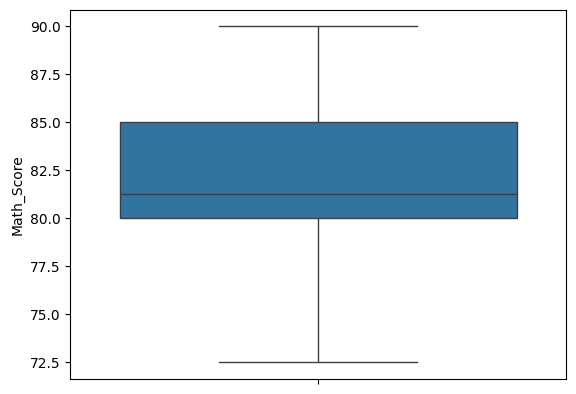

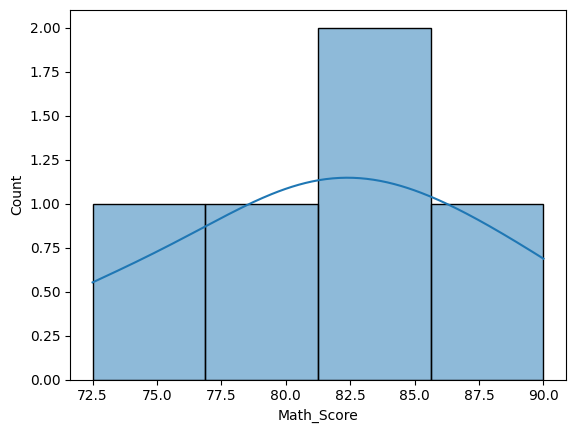

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot to visually identify outliers
sns.boxplot(df['Math_Score'])
plt.show()

# Histogram to visualize the distribution of data
sns.histplot(df['Math_Score'], kde=True)
plt.show()
# 3. Visual Methods (Boxplot, Histogram)
# Description: One of the most intuitive methods for detecting outliers is through visualization.

# Boxplots: Outliers are usually represented as points that fall outside the "whiskers" of the box plot (typically 1.5 * IQR).

# Histograms: A long tail on one side (skewed data) could indicate outliers, or a small number of very large/small values may appear as outliers in a histogram.

# Use Case: This is a quick and visual way to identify potential outliers, especially in small datasets or when you want a simple, non-quantitative check.